In [5]:
%conda install -c emscripten-forge pandas

mambajs 0.21.4

emscripten-forge channel alias is deprecated. Please use https://prefix.dev/emscripten-forge-3x explicitely.
Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge, emscripten-forge-3x

Solving environment...
Solving took 1.126 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

df = pd.read_csv("vgsales.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [6]:
df.shape

(16598, 11)

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.1 MB


#1 Problem Statements

I decided to go with the video game sales dataset from Kaggle. The dataset has 16,598 rows and 11 columns. The video game sales dataset includes game name, platform, year, genre, publisher, and the sales from different areas. The dataset also only includes games with sales greater than 100,000 copies.

Dataset source: https://www.kaggle.com/datasets/gregorut/videogamesales?resource=download

The main inquiry question: 
How have video game sales changed over time?

The sub questions: 
How have global video game sales changed from year to year?
How have sales for different video genres changed over time?
Has the number of video games released each year changed over time?

#2 Data Cleaning

In [8]:
# Check for missing values in each column
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
# Remove rows where the Year is missing
df = df.dropna(subset=["Year"])

# Check missing values again
df.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [10]:
# Drop columns that are not needed for this analysis
df = df.drop(columns=["Rank", "Publisher"])

# Check the remaining columns
df.info()

<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16327 non-null  str    
 1   Platform      16327 non-null  str    
 2   Year          16327 non-null  float64
 3   Genre         16327 non-null  str    
 4   NA_Sales      16327 non-null  float64
 5   EU_Sales      16327 non-null  float64
 6   JP_Sales      16327 non-null  float64
 7   Other_Sales   16327 non-null  float64
 8   Global_Sales  16327 non-null  float64
dtypes: float64(6), str(3)
memory usage: 1.1 MB


In [11]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
# Convert Year from float to integer
df["Year"] = df["Year"].astype(int)

# Check the data types
df.dtypes

Name                str
Platform            str
Year              int32
Genre               str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [13]:
# Check unique values in categorical columns
print("Platforms:")
print(sorted(df["Platform"].unique()))

print("\nGenres:")
print(sorted(df["Genre"].unique()))

Platforms:
['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']

Genres:
['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']


#All platforms and Genres are accurate with no inconsistencies found - No change

In [14]:
# Check summary statistics for numeric variables
df[["NA_Sales", "EU_Sales", "JP_Sales", 
    "Other_Sales", "Global_Sales"]].describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,0.265415,0.147554,0.078661,0.048325,0.540232
std,0.821591,0.508766,0.311557,0.189885,1.565732
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.000000,0.000000,0.000000,0.000000,0.060000
50%,0.080000,0.020000,0.000000,0.010000,0.170000
75%,0.240000,0.110000,0.040000,0.040000,0.480000
max,41.490000,29.020000,10.220000,10.570000,82.740000


In [15]:
# IQR method to check for potential outliers

Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Global_Sales"] < lower_bound) |
              (df["Global_Sales"] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Lower Bound: -0.5700000000000001
Upper Bound: 1.1099999999999999
Number of potential outliers: 1827


In [16]:
# Display the games with the highest global sales
df.sort_values("Global_Sales", ascending=False)[
    ["Name", "Year", "Genre", "Global_Sales"]
].head(10)

,Name,Year,Genre,Global_Sales
0,Wii Sports,2006,Sports,82.74
1,Super Mario Bros.,1985,Platform,40.24
2,Mario Kart Wii,2008,Racing,35.82
3,Wii Sports Resort,2009,Sports,33.00
4,Pokemon Red/Pokemon Blue,1996,Role-Playing,31.37
5,Tetris,1989,Puzzle,30.26
6,New Super Mario Bros.,2006,Platform,30.01
7,Wii Play,2006,Misc,29.02
8,New Super Mario Bros. Wii,2009,Platform,28.62
9,Duck Hunt,1984,Shooter,28.31


### Outlier Check

The IQR method identified 1,827 potential outliers in Global_Sales. 
After examining the highest values, these records appeared to represent 
legitimate high-selling video games rather than data errors. Since these 
games are important to the analysis of video game sales, the potential 
outliers were kept in the dataset.

In [17]:
# Check the range of years
print("Earliest Year:", df["Year"].min())
print("Latest Year:", df["Year"].max())

# Display the latest years
print(sorted(df["Year"].unique())[-10:])

Earliest Year: 1980
Latest Year: 2020
[np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2020)]


In [18]:
# Display the shape and information of the cleaned dataset
print("Cleaned dataset shape:", df.shape)
df.info()

Cleaned dataset shape: (16327, 9)
<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16327 non-null  str    
 1   Platform      16327 non-null  str    
 2   Year          16327 non-null  int32  
 3   Genre         16327 non-null  str    
 4   NA_Sales      16327 non-null  float64
 5   EU_Sales      16327 non-null  float64
 6   JP_Sales      16327 non-null  float64
 7   Other_Sales   16327 non-null  float64
 8   Global_Sales  16327 non-null  float64
dtypes: float64(5), int32(1), str(3)
memory usage: 1020.4 KB


In [19]:
# Reset the index after cleaning
df = df.reset_index(drop=True)

df.head()

,Name,Platform,Year,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.37


### 3 Exploritory data analysis and interpretation of the results

### Questions A: How have global video game sales changes from year to year

In [9]:
# Pivot table to display total global sales for each year
yearly_sales = df.pivot_table(
    values="Global_Sales",
    index="Year",
    aggfunc="sum"
)

yearly_sales

,Global_Sales
Year,
1980.0,11.38
1981.0,35.77
1982.0,28.86
1983.0,16.79
1984.0,50.36
1985.0,53.94
1986.0,37.07
1987.0,21.74
1988.0,47.22


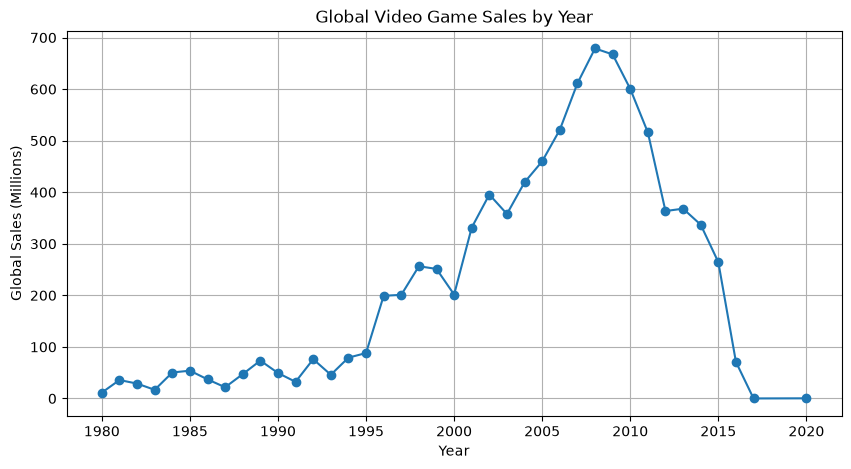

In [10]:
# Line graph for a visual representation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales["Global_Sales"],
    marker="o"
)

plt.title("Global Video Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid()

plt.show()

# Interpretation 

The graph shows that global video game sales had gradual increases from 1980 to 1995. 1995 was the begining of video games rising in sales continuing through 2008 which is the highest point in this graph. The graph then shows a substancial decrease in sales continuing into 2020. The data from 2014 through 2020 is not as robust as the rest of the data set and likely is not an accurate depiction of real video game sales during that time period. For instance the dataset only has one entry for 2020.

# Question B: How have sales for different video game genres changes over time?

In [12]:
# Create a pivot table showing global sales by year and genre
genre_sales = df.pivot_table(
    values="Global_Sales",
    index="Year",
    columns="Genre",
    aggfunc="sum",
    fill_value=0
)

genre_sales

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Year,,,,,,,,,,,,
1980.0,0.34,0.00,0.77,2.71,0.00,0.00,0.00,0.00,7.07,0.00,0.49,0.00
1981.0,14.84,0.00,0.00,0.00,6.93,2.24,0.48,0.00,10.04,0.45,0.79,0.00
1982.0,6.52,0.00,0.00,0.87,5.03,10.03,1.57,0.00,3.79,0.00,1.05,0.00
1983.0,2.86,0.40,0.00,2.14,6.93,0.78,0.00,0.00,0.48,0.00,3.20,0.00
1984.0,1.85,0.00,0.00,1.45,0.69,3.14,5.95,0.00,31.10,0.00,6.18,0.00
1985.0,3.52,0.00,1.05,0.00,43.17,3.21,0.00,0.00,1.00,0.03,1.96,0.00
1986.0,13.74,0.00,0.00,0.00,9.39,0.00,1.96,2.52,3.89,0.00,5.57,0.00
1987.0,1.12,4.38,5.42,0.00,1.74,0.00,0.00,4.65,0.71,0.00,3.72,0.00
1988.0,1.75,0.00,0.00,0.00,27.73,5.58,2.14,5.88,0.51,0.03,3.60,0.00


In [13]:
# Find the top 5 genres based on total global sales
top_genres = df.groupby("Genre")["Global_Sales"].sum().sort_values(
    ascending=False
).head(5)

top_genres

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Name: Global_Sales, dtype: float64

In [14]:
# Select the top 5 genres from the pivot table
top_genre_sales = genre_sales[top_genres.index]

top_genre_sales.head()

Genre,Action,Sports,Shooter,Role-Playing,Platform
Year,,,,,
1980.0,0.34,0.49,7.07,0.0,0.00
1981.0,14.84,0.79,10.04,0.0,6.93
1982.0,6.52,1.05,3.79,0.0,5.03
1983.0,2.86,3.20,0.48,0.0,6.93
1984.0,1.85,6.18,31.10,0.0,0.69


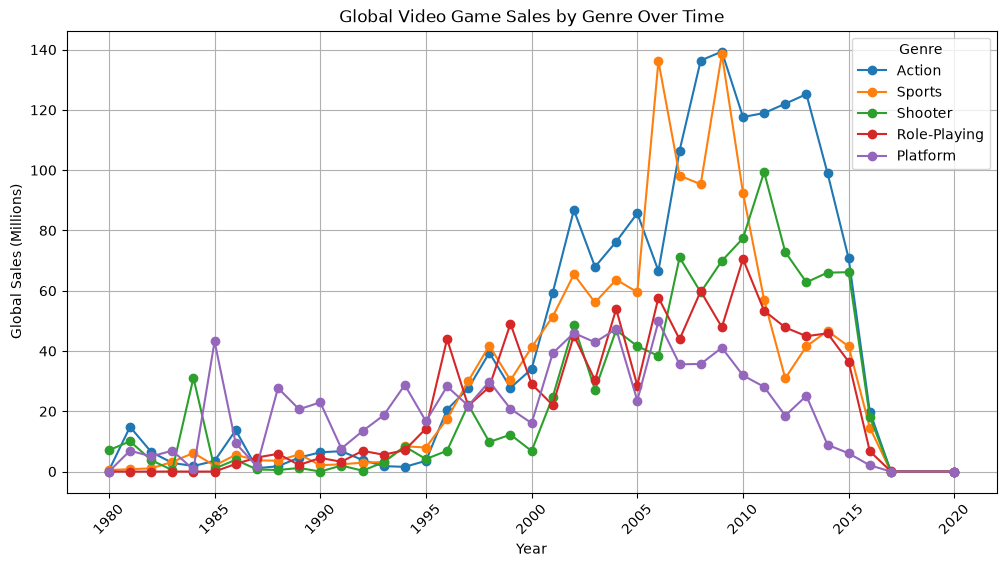

In [15]:
# Create a line graph for the top 5 genres
top_genre_sales.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Global Video Game Sales by Genre Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.legend(title="Genre")
plt.xticks(rotation=45)
plt.grid()

plt.show()

# Interpretation

The line chart shows that sales for the top 5 video game genres gradually increased from the 1990s to the 2000s. In the 2000s action games started having higher sales and continued being the highest seller through 2015. Sports games also saw an increase starting in 1998 until 2010 while shooter games saw an increase in later years. The combined total sales of the top 5 genres of games reached their peak in 2009 and then declined. The decline after 2014 should be reviewed carefully due to the dataset having a low number of entries after 2014.

# Question C:

Has the number of video games released each year changed over time?

In [17]:
# Count the number of video games released each year
games_per_year = df.groupby("Year")["Name"].count()

# Display the results
games_per_year

Year
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     349
2001.0     482
2002.0     829
2003.0     775
2004.0     763
2005.0     941
2006.0    1008
2007.0    1202
2008.0    1428
2009.0    1431
2010.0    1259
2011.0    1139
2012.0     657
2013.0     546
2014.0     582
2015.0     614
2016.0     344
2017.0       3
2020.0       1
Name: Name, dtype: int64

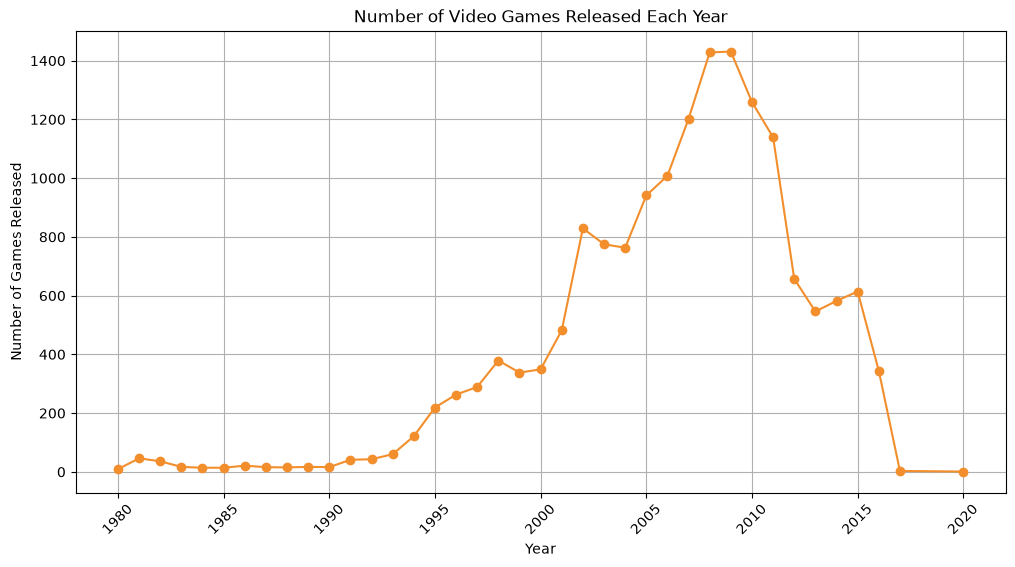

In [18]:
# Create a line graph showing the number of games released each year
plt.figure(figsize=(12, 6))

plt.plot(
    games_per_year.index,
    games_per_year.values,
    color="#f28e2c",
    marker="o"
)

plt.title("Number of Video Games Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Games Released")
plt.xticks(rotation=45)
plt.grid()

plt.show()

# Interpretation

The number of video games sold each year stayed fairly consistent from 1980 through 1994 with a spike in 1991 and 1994. The number of video games sold then starts to climb in 1995 until it reached the peak in 2008 and 2009 before gradually declining for a few years. The decline then drops from 2010 and 2011. However, the lower number of sales from 2011 through 2020 should not be considered the complete picture.

# 4 Summary

The goal of this this project was to determine how video game sales have changed over time. I was able to determine that in the 1980s through the 1990s the global video game sales was low but gradually increased. This is likely due to video games being invented in the 1950s and in the 1980s video became more commercialized. The data then shows in the late 1990s and 2000s that video games sales saw large increase. The global sales reached their highest in 2008 and 2009 before declining. When it comes to the genres, action games sales increased largely in the 2000s and early 2010s. In 2009, the number of games recorded released each year, reach its highest point with 1,431 games.

The main thing I was not able to determine was if the results from 2015 and later had a decline or increase due to the dataset lacking entries from that time period. There is not enough information provided for those years to come to a strong conclusion. The dataset also included platform games which included platform specific games such as Ratchet & Clank which could also fall under the action category. It also did not include if the sales were digital and game ratings which could have helped explain some of the changes in sales for the years they released.

In order to further explore about this topic, I would find a more up to date and complete dataset. I would also want the data set to include more information such as game ratings and digital vs physical sales. These two categories could help to provide a more complete analysis as to why the changes in sales happened. 